# Applying Spectral Derivative Pigment (SDP) Phytoplankton Community Composition Algorithm to OCI data

**Author(s):** Anna Windle (NASA, SSAI), Max Danenhower (Bowdoin College), Sasha Kramer (Boston University)

Last updated: June 25, 2026

<div class="alert alert-success" role="alert">

The following notebooks are **prerequisites** for this tutorial.

- Learn with OCI: [Data Access][oci-data-access]

</div>

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA ocean color data.

</div>

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: /notebooks/oci_data_access/

## Summary

This notebook applies the inversion algorithm described in [Kramer et al., 2022][Kramer-et-al] to estimate phytoplankton pigment concentrations from PACE OCI Rrs data. This algorithm, called Spectral Derivative Pigment (SDP), is currently being implemented in OBPG's OCSSW software. This work was originally [developed in MatLab](https://github.com/sashajane19/Rrs_pigments) by Sasha Kramer and subsequently [translated to Python](https://github.com/max-danenhower/rrs-SDP-pigments/) by Max Danenhower. This tutorial demonstrates how to apply the Python SDP algorithm to Level-2 (L2) and Level-3 Mapped (L3M) PACE OCI data.

[Kramer-et-al]: https://doi.org/10.1016/j.rse.2021.112879

## Learning Objectives

At the end of this notebook you will know:

- How to use a packaged Python project
- How to run the SDP Algorithm on PACE OCI L2 and L3 data

## 1. Setup

The SDP Python code has been packaged to allow it to be easily installed, imported, and reused.
While the package is not on PyPI or conda-forge, it can be installed directly from the [source repository][sdp] on GitHub.
If you have followed the setup instructions, then GPig is available to import along with the other packages needed for this notebook.

[sdp]: https://github.com/max-danenhower/rrs-SDP-pigments/

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

crs = ccrs.PlateCarree()

In [2]:
pip install ray openpyxl #scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("src").resolve()))
import sdp

In [4]:
import sdp
print(sdp.__file__)

/glusteruser/awindled/rrs-SDP-pigments/src/sdp/__init__.py


In [5]:
from sdp import rrsModelTrain

Set (and persist to your home directory on the host, if needed) your Earthdata Login credentials.

In [6]:
auth = earthaccess.login()

In [7]:
results = earthaccess.search_data(
    short_name=["PACE_OCI_L2_AOP_NRT"],
    temporal= ("2026-03-03", "2026-03-03"),
    granule_name='*20260303T183722*')
results

[Collection: {'ShortName': 'PACE_OCI_L2_AOP_NRT', 'Version': '3.1'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 19.17521, 'Longitude': -76.59177}, {'Latitude': 14.03287, 'Longitude': -101.24934}, {'Latitude': -3.72917, 'Longitude': -97.05262}, {'Latitude': 1.30772, 'Longitude': -73.34698}, {'Latitude': 19.17521, 'Longitude': -76.59177}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2026-03-03T18:37:22Z', 'EndingDateTime': '2026-03-03T18:42:21Z'}}
 Size(MB): 431.48643684387207
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260303T183722.L2.OC_AOP.V3_1.NRT.nc']]

In [8]:
paths = earthaccess.open(results)
paths

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[<File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260303T183722.L2.OC_AOP.V3_1.NRT.nc>]

In [9]:
paths[0]

<File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20260303T183722.L2.OC_AOP.V3_1.NRT.nc>

## 2. Run SDP on L2 Data

In [10]:
from sdp.core import sdp_from_pace

In [11]:
def load_data(tspan):
    '''
    Downloads one L2 PACE apparent optical properties (AOP) file that intersects the coordinate box passed in, as well as 
    temperature and salinity files. Data files are saved to local folders named 'L2_rrs_data', 'sal_data', and 'temp_data'.

    Parameters:
    -----------
    tspan : tuple of str
        A tuple containing two strings both with format 'YYYY-MM-DD'. The first date in the tuple must predate the second date in the tuple.
    bbox : tuple of floats or ints
        A tuple representing spatial bounds in the form (lower_left_lon, lower_left_lat, upper_right_lon, upper_right_lat).

    Returns:
    --------
    list
        A list of file paths to a PACE L2 AOP files intersecting the passed in bounding box.
    string
        A single file path to a salinity file.
    string
        A single file path to a temperature file.
    '''

    #L2_results = earthaccess.search_data(
    #    short_name='PACE_OCI_L2_AOP',
    #    bounding_box=bbox,
    #    temporal=tspan
    #)
    #if (len(L2_results) > 0):
    #    L2_paths = earthaccess.download(L2_results, 'L2_rrs_data')
    #else:
    #    L2_paths = []
     #   print('No L2 AOP data found')

    sal_results = earthaccess.search_data(
        short_name='SMAP_JPL_L3_SSS_CAP_8DAY-RUNNINGMEAN_V5',
        temporal=tspan,
        count=1
    )
    if (len(sal_results) > 0):
        sal_paths = earthaccess.download(sal_results, 'sal_data')
    else:
        sal_paths = []
        print('No salinity data found')

    temp_results = earthaccess.search_data(
        short_name='MUR-JPL-L4-GLOB-v4.1',
        temporal=tspan,
        count=1
    )
    if (len(temp_results) > 0):
        temp_paths = earthaccess.download(temp_results, 'temp_data')
    else:
        temp_paths = []
        print('No temperature data found')

    return sal_paths[0], temp_paths[0]

load_data(tspan = ("2026-03-03", "2026-03-03"))

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

(PosixPath('sal_data/SMAP_L3_SSS_20260227_8DAYS_V5.0.nc'),
 PosixPath('temp_data/20260303090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc'))

In [11]:
output_file = paths[0].full_name.split("/")[-1]
output_file = output_file.replace(".nc", "_SDP_pigments.nc")
output_file

'PACE_OCI.20260303T183722.L2.OC_AOP.V3_1.NRT_SDP_pigments.nc'

In [12]:
%%time

sdp_from_pace(paths[0], output_file, 
             sss_file='/glusteruser/awindled/rrs-SDP-pigments/sal_data/SMAP_L3_SSS_20260227_8DAYS_V5.0.nc',
             sst_file='/glusteruser/awindled/rrs-SDP-pigments/temp_data/20260303090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc')

generating pigments from PACE
starting interpolation
north 19.175207 south -3.7291718 east -73.346985 west -101.24934


/glusteruser/awindled/rrs-SDP-pigments/src/sdp/core.py:220: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(temp_path) as ds:
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/core.py:222: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray

interpolation complete: 62.25407696282491
rrs_interp shape: (2175120, 374)
(1058756,) (1058756,) (1058756, 301)
0
calculating residuals


/glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:328: RuntimeWarning: overflow encountered in power
  bbp = (443 / wavelengths.reshape(-1, 1)) ** bbp_s
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:201: RuntimeWarning: invalid value encountered in power
  aph = A * IOPs[0]**B
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:204: RuntimeWarning: invalid value encountered in divide
  x = bb / (a + bb)
/glusteruser/awindled/rrs-SDP-pigments/src/sdp/Kramer_hyperRrs.py:402: RuntimeWarning: invalid value encountered in divide
  rrsP = bb / (a + bb)


residuals calculated 10566.086172934156
calculating 2nd derivative
2nd derivative calculated 1.1796440230682492
(1058756, 299)
running coefs
coefs run complete 29.276644703932106
sdp calculation complete
CPU times: user 2h 59min 40s, sys: 26.7 s, total: 3h 6s
Wall time: 2h 57min 51s


In [19]:
dat_v32 = xr.open_dataset('PACE_OCI.20260303T183722.L2.OC_AOP.V3_2_SDP_pigments.nc')
dat_v31 = xr.open_dataset('PACE_OCI.20260303T183722.L2.OC_AOP.V3_1.NRT_SDP_pigments.nc')

dat_v31

<xarray.Dataset> Size: 244MB
Dimensions:          (number_of_lines: 1710, pixels_per_line: 1272)
Coordinates:
  * number_of_lines  (number_of_lines) int64 14kB 0 1 2 3 ... 1707 1708 1709
  * pixels_per_line  (pixels_per_line) int64 10kB 0 1 2 3 ... 1269 1270 1271
    longitude        (number_of_lines, pixels_per_line) float32 9MB ...
    latitude         (number_of_lines, pixels_per_line) float32 9MB ...
Data variables: (12/13)
    chla             (number_of_lines, pixels_per_line) float64 17MB ...
    chlb             (number_of_lines, pixels_per_line) float64 17MB ...
    chlc             (number_of_lines, pixels_per_line) float64 17MB ...
    zea              (number_of_lines, pixels_per_line) float64 17MB ...
    dvchla           (number_of_lines, pixels_per_line) float64 17MB ...
    butfuco          (number_of_lines, pixels_per_line) float64 17MB ...
    ...               ...
    allo             (number_of_lines, pixels_per_line) float64 17MB ...
    neo              (number_of_lines, pixels_per_line) float64 17MB ...
    viola            (number_of_lines, pixels_per_line) float64 17MB ...
    fuco             (number_of_lines, pixels_per_line) float64 17MB ...
    chlc3            (number_of_lines, pixels_per_line) float64 17MB ...
    perid            (number_of_lines, pixels_per_line) float64 17MB ...

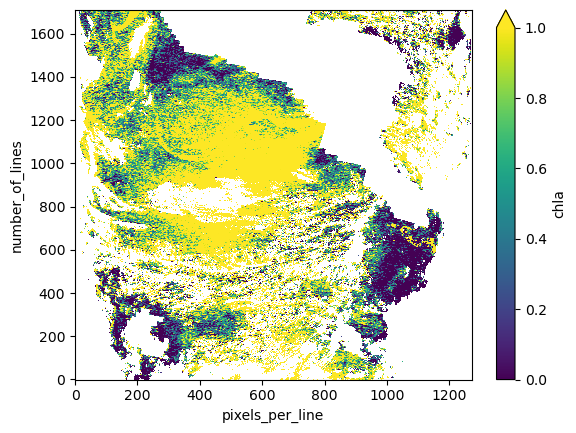

In [14]:
dat.chla.plot(vmax=1)

/tmp/ipykernel_2810863/1470844703.py:20: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


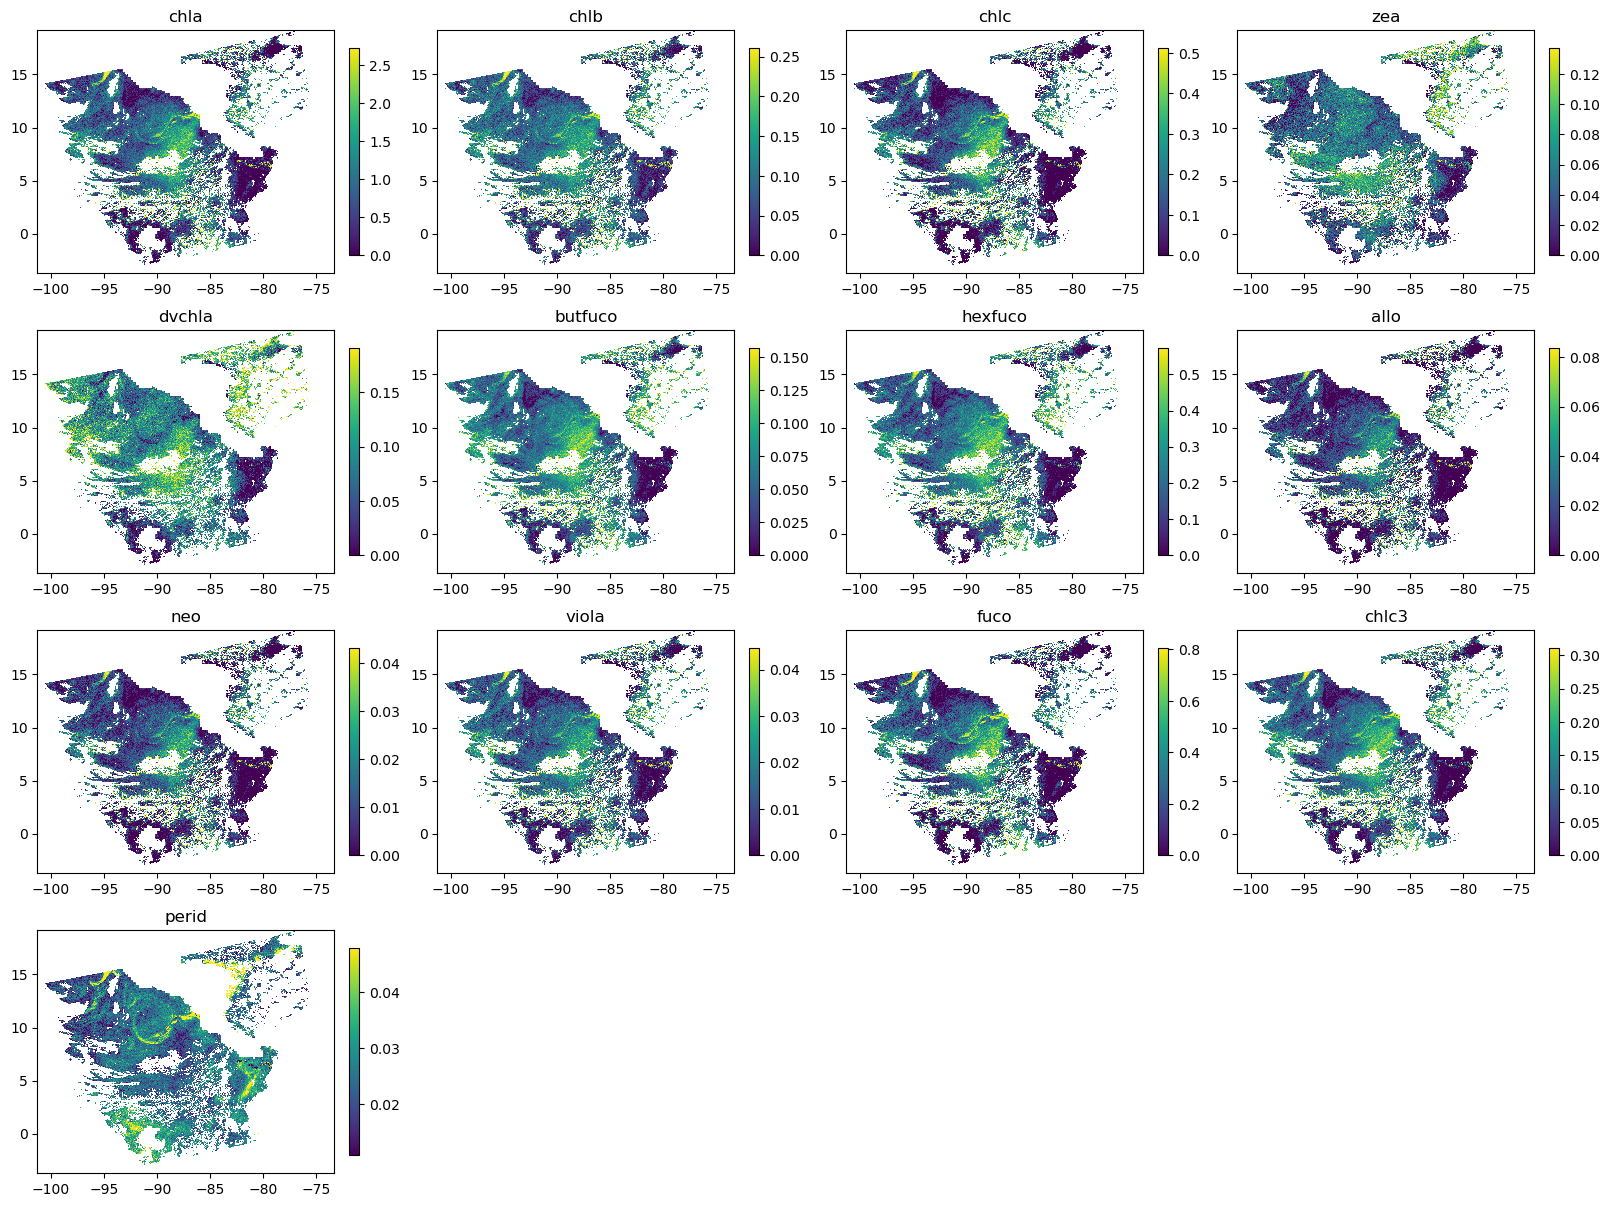

In [20]:
import matplotlib.pyplot as plt
import numpy as np

vars_to_plot = list(dat_v31.data_vars)

ncols = 4
nrows = int(np.ceil(len(vars_to_plot) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4 * ncols, 3 * nrows),
    constrained_layout=True
)

axes = axes.ravel()

for ax, var in zip(axes, vars_to_plot):

    im = ax.pcolormesh(
        dat_v31.longitude,
        dat_v31.latitude,
        dat_v31[var],
        shading="auto",
        vmin = np.nanpercentile(dat[var], 2),
        vmax = np.nanpercentile(dat[var], 98)
    )

    ax.set_title(var)
    ax.set_aspect("equal")

    plt.colorbar(im, ax=ax, shrink=0.8)

for ax in axes[len(vars_to_plot):]:
    ax.remove()

plt.show()

In [21]:
jakob_dat = xr.open_dataset('/glusteruser/jlindo1/sdp/PACE_OCI.20260303T183722.L2.SDP.nc')
jakob_dat

<xarray.Dataset> Size: 244MB
Dimensions:          (number_of_lines: 1710, pixels_per_line: 1272)
Coordinates:
  * number_of_lines  (number_of_lines) int64 14kB 0 1 2 3 ... 1707 1708 1709
  * pixels_per_line  (pixels_per_line) int64 10kB 0 1 2 3 ... 1269 1270 1271
    longitude        (number_of_lines, pixels_per_line) float32 9MB ...
    latitude         (number_of_lines, pixels_per_line) float32 9MB ...
Data variables: (12/13)
    chla             (number_of_lines, pixels_per_line) float64 17MB ...
    chlb             (number_of_lines, pixels_per_line) float64 17MB ...
    chlc             (number_of_lines, pixels_per_line) float64 17MB ...
    zea              (number_of_lines, pixels_per_line) float64 17MB ...
    dvchla           (number_of_lines, pixels_per_line) float64 17MB ...
    butfuco          (number_of_lines, pixels_per_line) float64 17MB ...
    ...               ...
    allo             (number_of_lines, pixels_per_line) float64 17MB ...
    neo              (number_of_lines, pixels_per_line) float64 17MB ...
    viola            (number_of_lines, pixels_per_line) float64 17MB ...
    fuco             (number_of_lines, pixels_per_line) float64 17MB ...
    chlc3            (number_of_lines, pixels_per_line) float64 17MB ...
    perid            (number_of_lines, pixels_per_line) float64 17MB ...

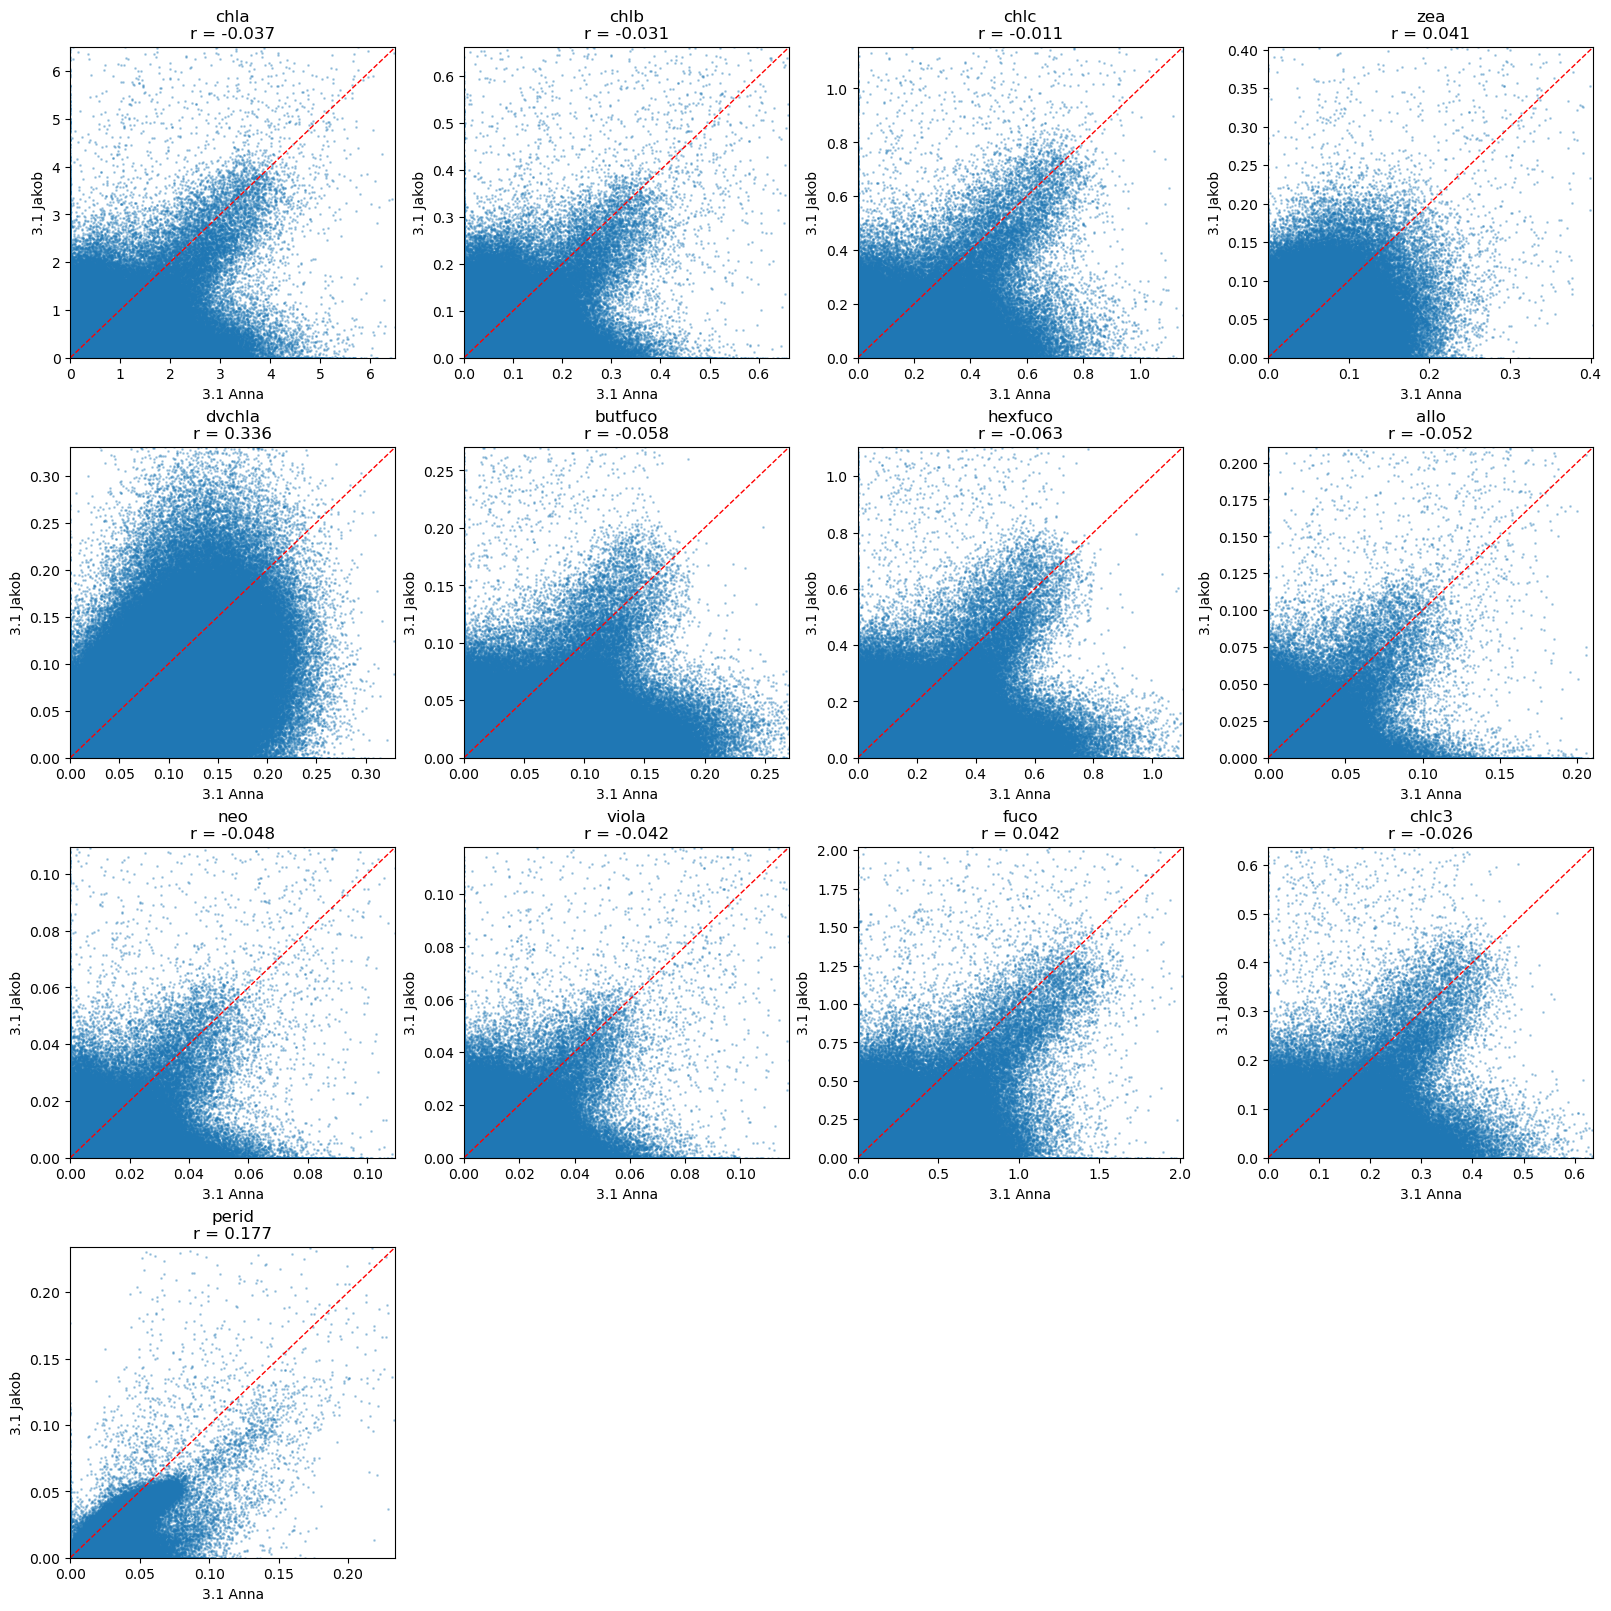

In [22]:
import numpy as np
import matplotlib.pyplot as plt

variables = [
    "chla", "chlb", "chlc", "zea", "dvchla",
    "butfuco", "hexfuco", "allo", "neo",
    "viola", "fuco", "chlc3", "perid"
]

nvars = len(variables)
ncols = 4
nrows = int(np.ceil(nvars / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4*ncols, 4*nrows),
    constrained_layout=True
)

axes = axes.ravel()

for ax, var in zip(axes, variables):

    x = dat_v31[var].values.ravel()
    y = jakob_dat[var].values.ravel()

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=1, alpha=0.3)
    #ax.hexbin(x, y, gridsize=100, mincnt=1)

    p1 = np.nanpercentile(np.concatenate([x, y]), .001)
    p99 = np.nanpercentile(np.concatenate([x, y]), 99.99)
    
    ax.set_xlim(p1, p99)
    ax.set_ylim(p1, p99)
    #ax.plot([p1, p99], [p1, p99], 'r--', lw=1)

    # 1:1 line
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1)

    # Correlation
    r = np.corrcoef(x, y)[0, 1]

    ax.set_title(f"{var}\nr = {r:.3f}")
    ax.set_xlabel("3.1 Anna")
    ax.set_ylabel("3.1 Jakob")

# Remove unused axes
for ax in axes[nvars:]:
    ax.remove()

plt.show()

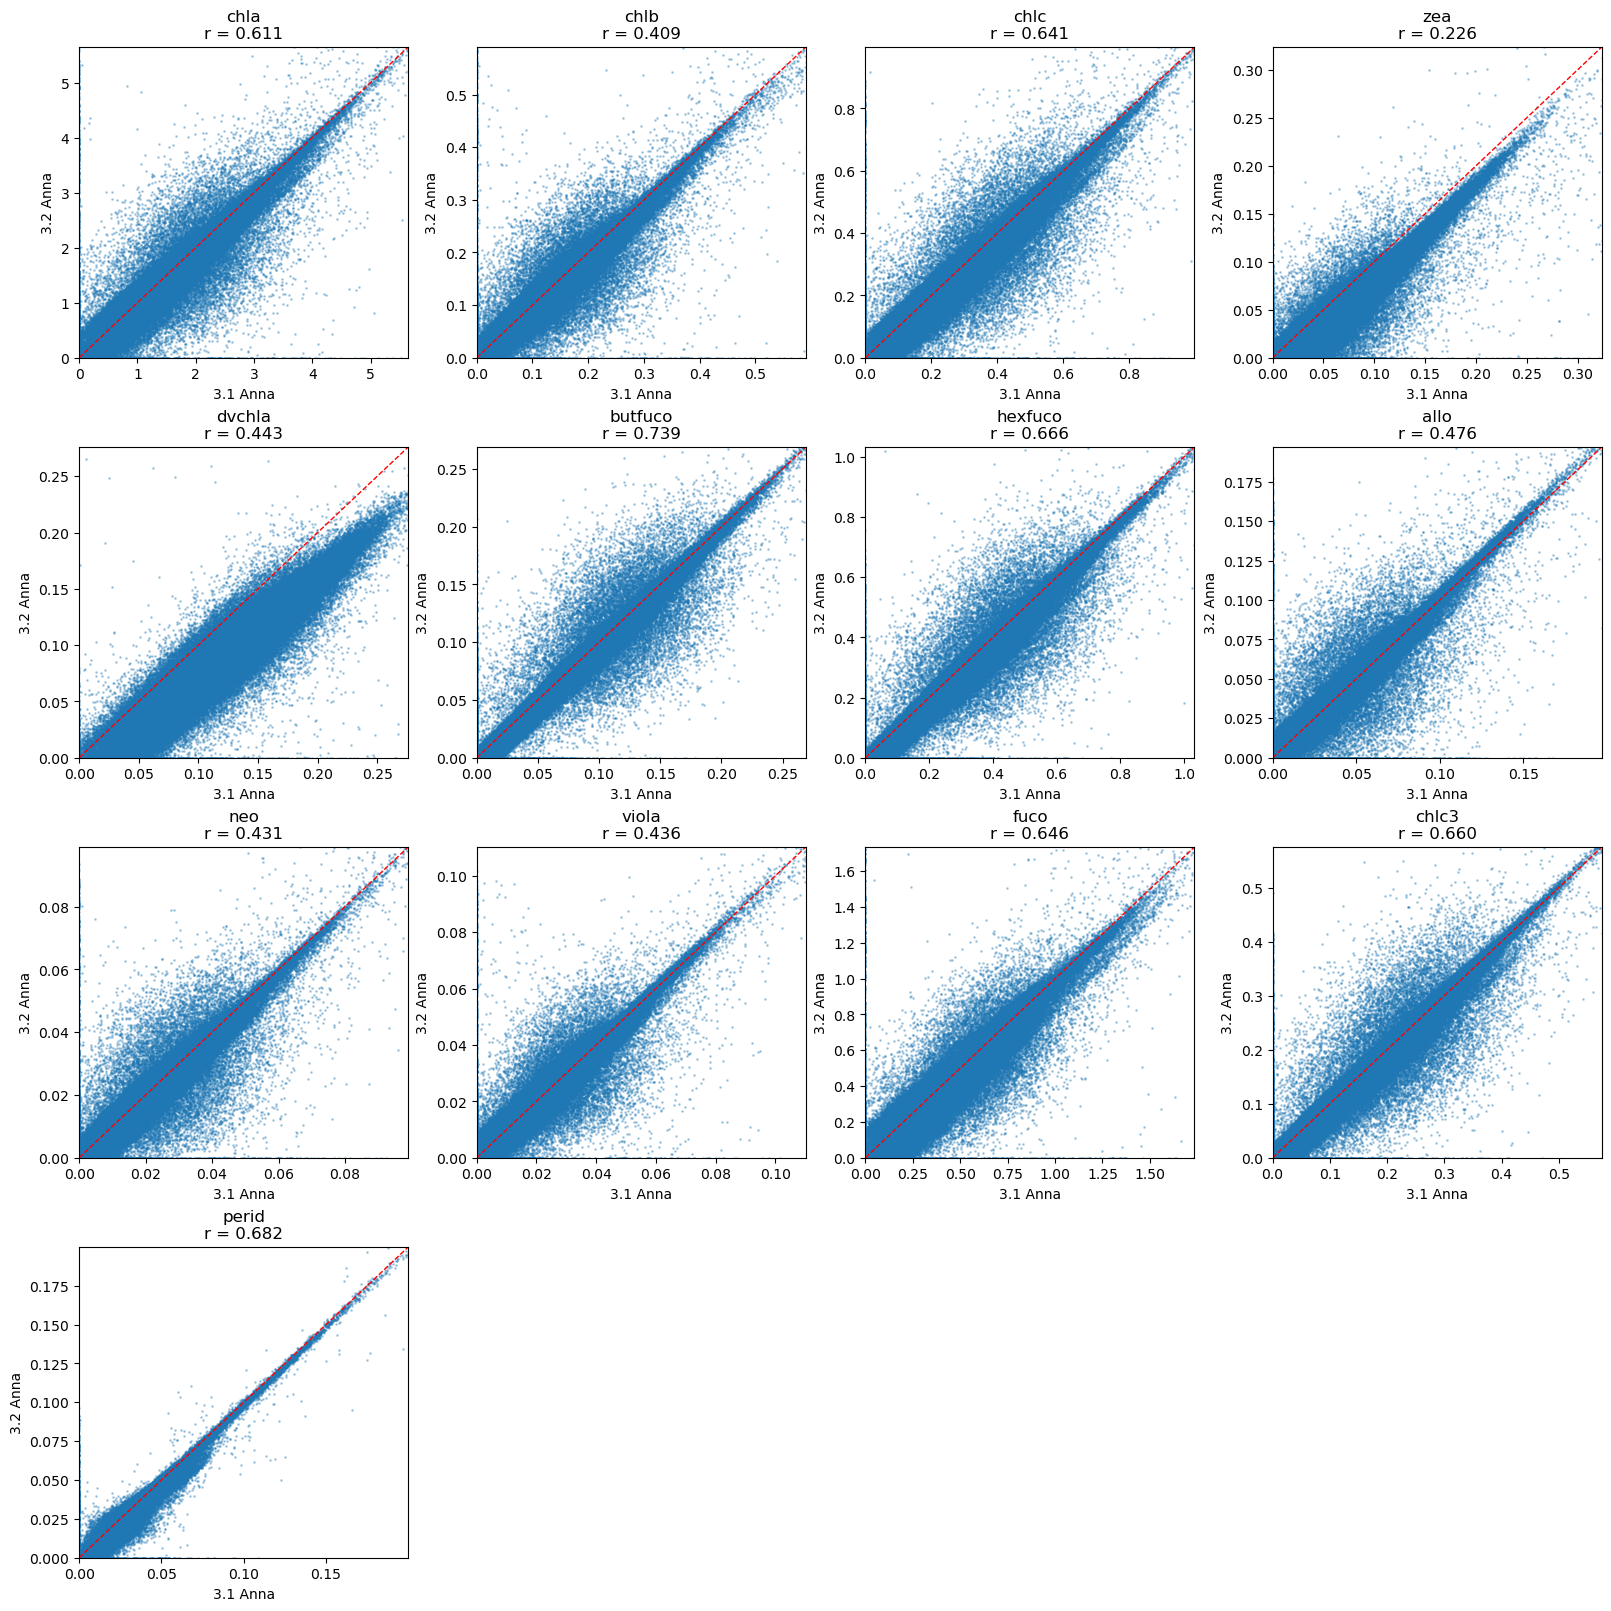

In [23]:
import numpy as np
import matplotlib.pyplot as plt

variables = [
    "chla", "chlb", "chlc", "zea", "dvchla",
    "butfuco", "hexfuco", "allo", "neo",
    "viola", "fuco", "chlc3", "perid"
]

nvars = len(variables)
ncols = 4
nrows = int(np.ceil(nvars / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4*ncols, 4*nrows),
    constrained_layout=True
)

axes = axes.ravel()

for ax, var in zip(axes, variables):

    x = dat_v31[var].values.ravel()
    y = dat_v32[var].values.ravel()

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=1, alpha=0.3)
    #ax.hexbin(x, y, gridsize=100, mincnt=1)

    p1 = np.nanpercentile(np.concatenate([x, y]), .001)
    p99 = np.nanpercentile(np.concatenate([x, y]), 99.99)
    
    ax.set_xlim(p1, p99)
    ax.set_ylim(p1, p99)
    #ax.plot([p1, p99], [p1, p99], 'r--', lw=1)

    # 1:1 line
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1)

    # Correlation
    r = np.corrcoef(x, y)[0, 1]

    ax.set_title(f"{var}\nr = {r:.3f}")
    ax.set_xlabel("3.1 Anna")
    ax.set_ylabel("3.2 Anna")

# Remove unused axes
for ax in axes[nvars:]:
    ax.remove()

plt.show()